In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Load data
df = pd.read_csv('/Users/mac/Documents/WB DSI/Karrierecoaching/autoscaut24_project//autoscout24.csv')


# Basic statistics
print(f"Total cars in dataset: {df.shape[0]}")
print(f"Sales period: from {df['year'].min()} to {df['year'].max()} year")
print("\nMissing values per column:")
print(df.isnull().sum())


Total cars in dataset: 46405
Sales period: from 2011 to 2021 year

Missing values per column:
mileage        0
make           0
model        143
fuel           0
gear         182
offerType      0
price          0
hp            29
year           0
dtype: int64


In [21]:
# 1. Remove rows with missing values
df_cleaned = df.dropna()

print(f"Rows before: {len(df)}")
print(f"Rows after removing missing values: {len(df_cleaned)}")

# 2. Find top 5 manufacturers
top_5_makes = df_cleaned['make'].value_counts().head(5).index.tolist()
print(f"\nTop 5 makes: {top_5_makes}")

# 3. Keep only these 5 makes
df_ml = df_cleaned[df_cleaned['make'].isin(top_5_makes)].copy()

print(f"Dataset size for Machine Learning: {df_ml.shape}")

Rows before: 46405
Rows after removing missing values: 46071

Top 5 makes: ['Volkswagen', 'Opel', 'Ford', 'Skoda', 'Renault']
Dataset size for Machine Learning: (21772, 9)


In [22]:
# Save clean data for Tableau
df_cleaned.to_csv('autoscout24_clean.csv', index=False)
print(f"✅ autoscout24_clean.csv saved ({len(df_cleaned)} rows)")

df_ml.to_csv('autoscout24_top5.csv', index=False)
print(f"✅ autoscout24_top5.csv saved ({len(df_ml)} rows)")

✅ autoscout24_clean.csv saved (46071 rows)
✅ autoscout24_top5.csv saved (21772 rows)


All Car Makes: 71
Top 5 Most Popular Car Makes: ['BMW' 'Volkswagen' 'SEAT' 'Renault' 'Peugeot']


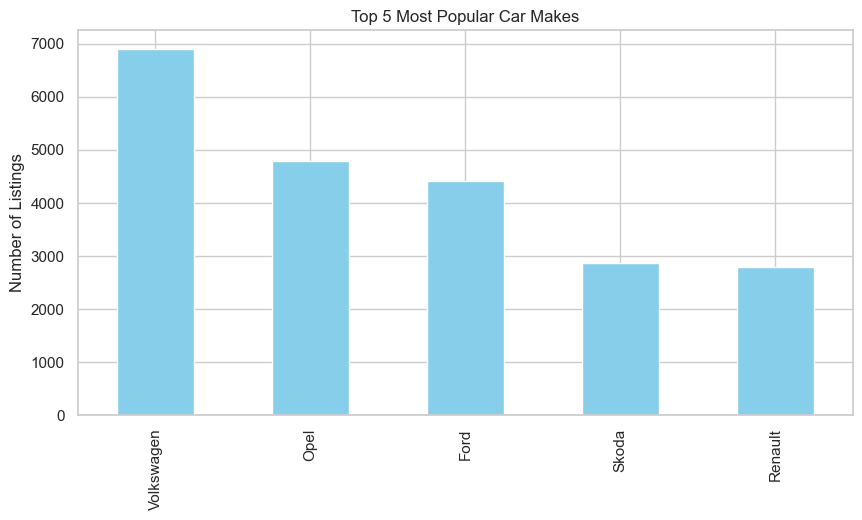

In [41]:
all_makes = df_cleaned['make'].unique()
print(f"All Car Makes: {len(all_makes)}")
print("Top 5 Most Popular Car Makes:", all_makes[:5])

# TOP 5 Chart
plt.figure(figsize=(10, 5))
df_cleaned['make'].value_counts().head(5).plot(kind='bar', color='skyblue')
plt.title('Top 5 Most Popular Car Makes')
plt.ylabel('Number of Listings')
plt.xlabel('')
plt.show()

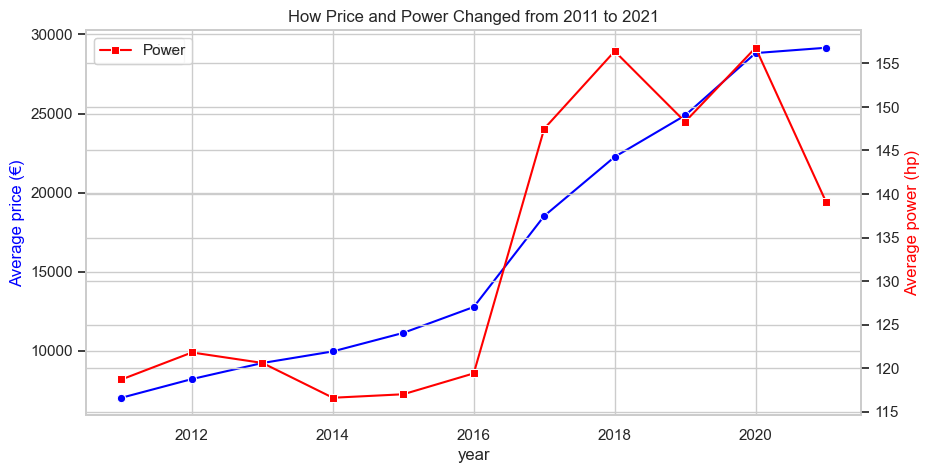

In [43]:
# Group data by year
yearly_trends = df_cleaned.groupby('year')[['price', 'hp']].mean().round(1)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

sns.lineplot(data=yearly_trends, x=yearly_trends.index, y='price', ax=ax1, color='blue', marker='o', label='Price')
sns.lineplot(data=yearly_trends, x=yearly_trends.index, y='hp', ax=ax2, color='red', marker='s', label='Power')

ax1.set_ylabel('Average price (€)', color='blue')
ax2.set_ylabel('Average power (hp)', color='red')
plt.title('How Price and Power Changed from 2011 to 2021')
plt.show()

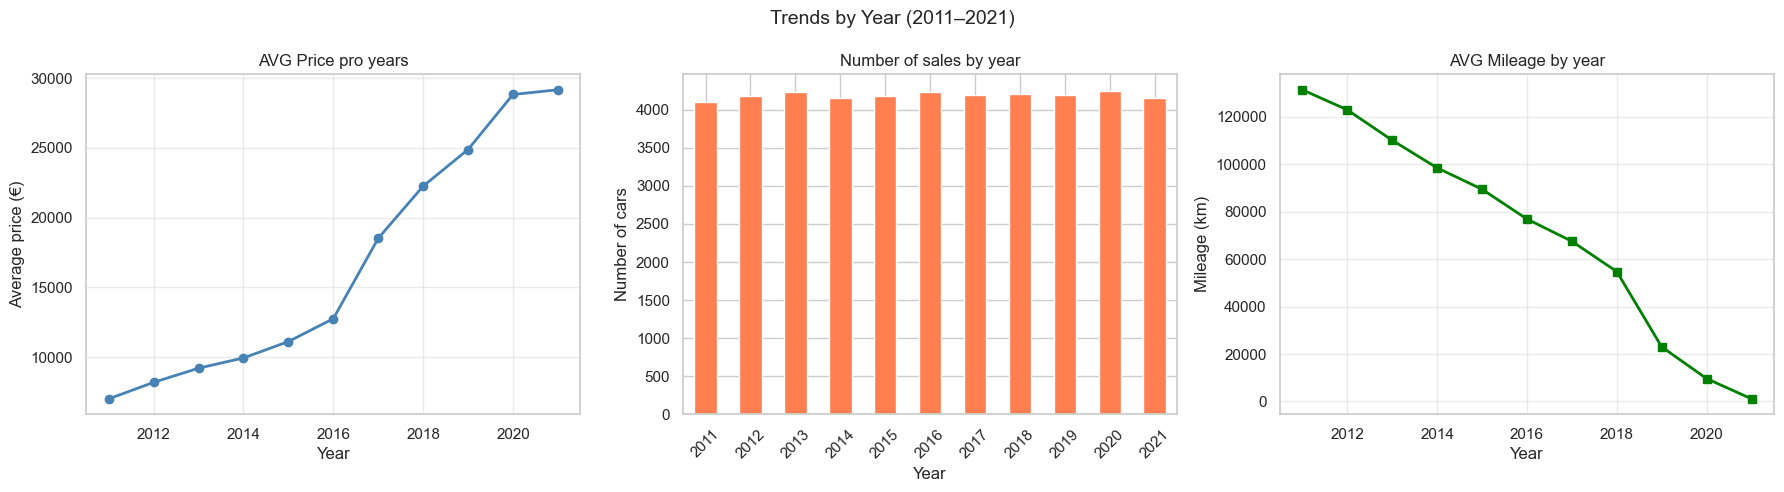

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. AVG Price by year
df_cleaned.groupby('year')['price'].mean().plot(
    ax=axes[0], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('AVG Price pro years')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average price (€)')
axes[0].grid(True, alpha=0.4)

# 2. Number of sales by year
df_cleaned['year'].value_counts().sort_index().plot(
    ax=axes[1], kind='bar', color='coral', edgecolor='white')
axes[1].set_title('Number of sales by year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of cars')
axes[1].tick_params(axis='x', rotation=45)

# 3. AVG Mileage by year
df_cleaned.groupby('year')['mileage'].mean().plot(
    ax=axes[2], marker='s', color='green', linewidth=2)
axes[2].set_title('AVG Mileage by year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Mileage (km)')
axes[2].grid(True, alpha=0.4)

plt.suptitle('Trends by Year (2011–2021)', fontsize=14)
plt.tight_layout()
plt.show()

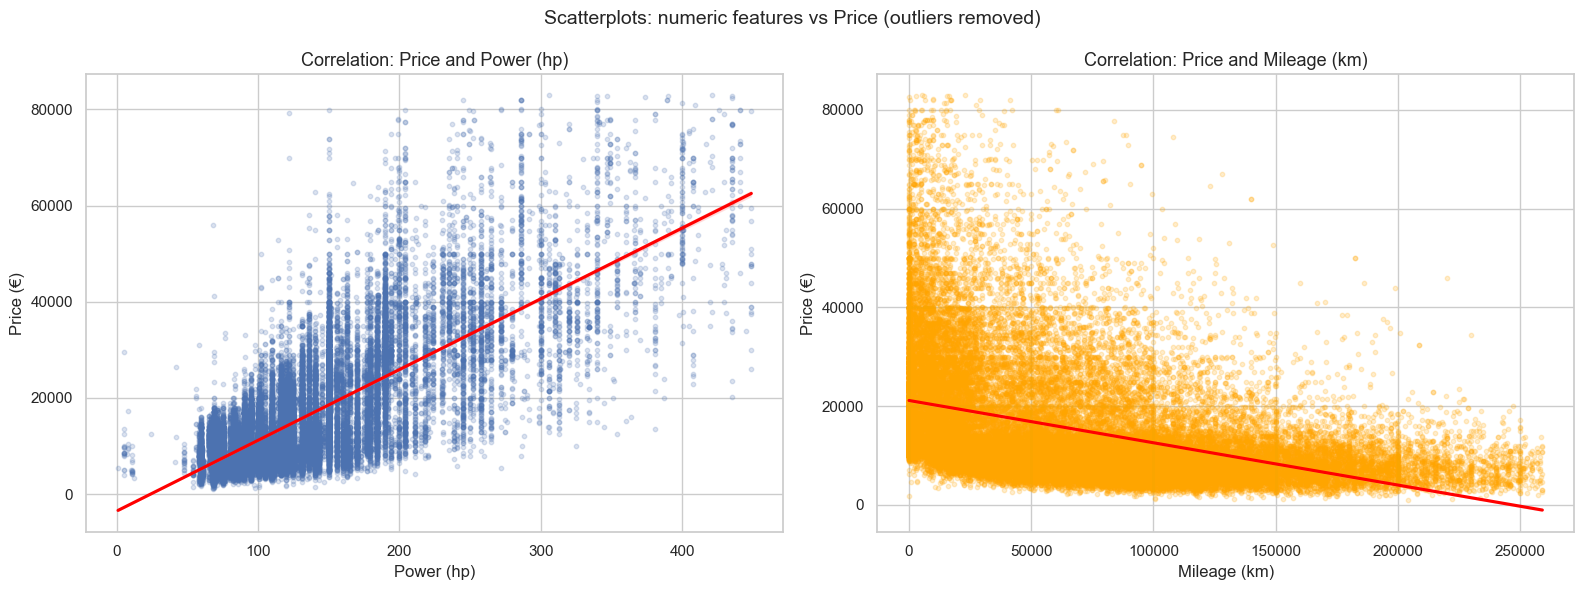

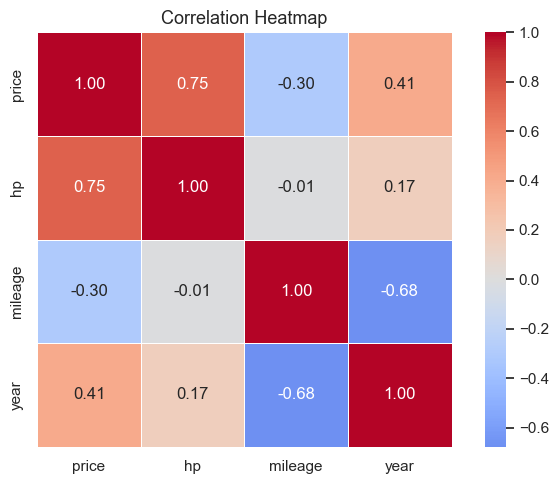

Key findings:
  hp      → price: +0.75 (strong positive correlation: more power = higher price)
  year    → price: +0.41 (newer = more expensive)
  mileage → price: -0.30 (more mileage = cheaper)


In [45]:
# Remove outliers (top 1%) for readable charts
df_plot = df_cleaned[
    (df_cleaned['price']   < df_cleaned['price'].quantile(0.99)) &
    (df_cleaned['hp']      < df_cleaned['hp'].quantile(0.99)) &
    (df_cleaned['mileage'] < df_cleaned['mileage'].quantile(0.99))
].copy()

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Price vs Power
sns.regplot(data=df_plot, x='hp', y='price',
            scatter_kws={'alpha': 0.2, 's': 10},
            line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title('Correlation: Price and Power (hp)', fontsize=13)
axes[0].set_xlabel('Power (hp)')
axes[0].set_ylabel('Price (€)')

# 2. Price vs Mileage
sns.regplot(data=df_plot, x='mileage', y='price',
            scatter_kws={'alpha': 0.2, 's': 10, 'color': 'orange'},
            line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Correlation: Price and Mileage (km)', fontsize=13)
axes[1].set_xlabel('Mileage (km)')
axes[1].set_ylabel('Price (€)')

plt.suptitle('Scatterplots: numeric features vs Price (outliers removed)', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(7, 5))
corr = df_cleaned[['price', 'hp', 'mileage', 'year']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

print('Key findings:')
print('  hp      → price: +0.75 (strong positive correlation: more power = higher price)')
print('  year    → price: +0.41 (newer = more expensive)')
print('  mileage → price: -0.30 (more mileage = cheaper)')

In [46]:
avg_price = df_ml.groupby('make')['price'].mean().round(1).sort_values(ascending=False)

print('Average Car Price by Make (in Euros):')
print(avg_price)


Average Car Price by Make (in Euros):
make
Volkswagen    16067.5
Ford          13781.1
Skoda         13720.2
Renault       11335.9
Opel          10422.4
Name: price, dtype: float64


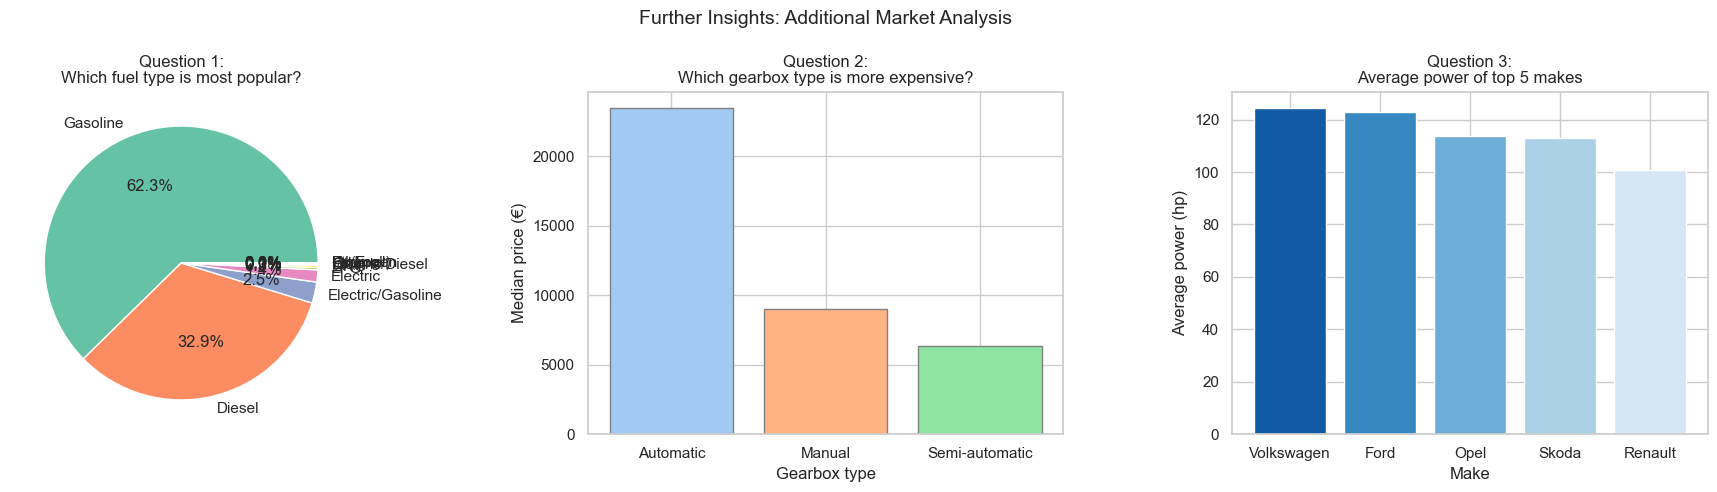

Key findings:
1. Petrol is the most popular fuel type, diesel in second place
2. Automatic gearbox cars are noticeably more expensive than manual
3. Volkswagen has the highest average power among the top 5 makes


In [47]:
# FURTHER INSIGHTS: ADDITIONAL ANALYSIS QUESTIONS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1: Which fuel type is most popular? ---
fuel_counts = df_cleaned['fuel'].value_counts()
axes[0].pie(fuel_counts.values, labels=fuel_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[0].set_title('Question 1:\nWhich fuel type is most popular?', fontsize=12)

# Which gearbox type is more expensive? ---
gear_price = df_cleaned.groupby('gear')['price'].median().sort_values(ascending=False)
axes[1].bar(gear_price.index, gear_price.values,
            color=sns.color_palette('pastel', len(gear_price)), edgecolor='gray')
axes[1].set_title('Question 2:\nWhich gearbox type is more expensive?', fontsize=12)
axes[1].set_xlabel('Gearbox type')
axes[1].set_ylabel('Median price (€)')

# 3: Which of the top 5 makes has the highest average power? ---
avg_hp = df_ml.groupby('make')['hp'].mean().sort_values(ascending=False)
axes[2].bar(avg_hp.index, avg_hp.values,
            color=sns.color_palette('Blues_r', len(avg_hp)))
axes[2].set_title('Question 3:\nAverage power of top 5 makes', fontsize=12)
axes[2].set_xlabel('Make')
axes[2].set_ylabel('Average power (hp)')

plt.suptitle('Further Insights: Additional Market Analysis', fontsize=14)
plt.tight_layout()
plt.show()

print('Key findings:')
print('1. Petrol is the most popular fuel type, diesel in second place')
print('2. Automatic gearbox cars are noticeably more expensive than manual')
print('3. Volkswagen has the highest average power among the top 5 makes')


In [48]:
# Select features for price prediction
# Features: mileage, horsepower, year, fuel type, gearbox
features = ['mileage', 'hp', 'year', 'make', 'fuel', 'gear']
X = df_ml[features]
y = df_ml['price'] # Target variable (what we predict)

# Convert categorical variables to numbers (One-Hot Encoding)
X_encoded = pd.get_dummies(X, columns=['make', 'fuel', 'gear'], drop_first=True)

print("Feature table ready!")
print(f"New number of columns: {X_encoded.shape[1]}")
X_encoded.head()

Feature table ready!
New number of columns: 18


,mileage,hp,year,make_Opel,make_Renault,make_Skoda,make_Volkswagen,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_Electric/Diesel,fuel_Electric/Gasoline,fuel_Ethanol,fuel_Gasoline,fuel_LPG,fuel_Others,gear_Manual,gear_Semi-automatic
1,92800,122.0,2011,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False
3,96200,110.0,2011,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False
6,91894,131.0,2011,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False
7,127500,116.0,2011,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False
9,104,86.0,2011,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# 2. Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Make predictions on test data
y_pred = model.predict(X_test)

# 4. Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.1f} €")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 2704.3 €
R-squared (R2): 0.80


In [50]:
from sklearn.ensemble import RandomForestRegressor

# 1. Create Random Forest model (100 trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model (may take 10-20 seconds longer)
rf_model.fit(X_train, y_train)

# 3. Make predictions
y_pred_rf = rf_model.predict(X_test)

# 4. Calculate metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf:.1f} €")
print(f"Random Forest - R2: {r2_rf:.2f}")

Random Forest - MAE: 1615.0 €
Random Forest - R2: 0.91


Gradient Boosting - MAE: 1643.3 €
Gradient Boosting - R2:  0.91

MODEL COMPARISON
            Model     MAE (€)       R²
Linear Regression 2704.300000 0.800000
    Random Forest 1615.000000 0.910000
Gradient Boosting 1643.265743 0.914486


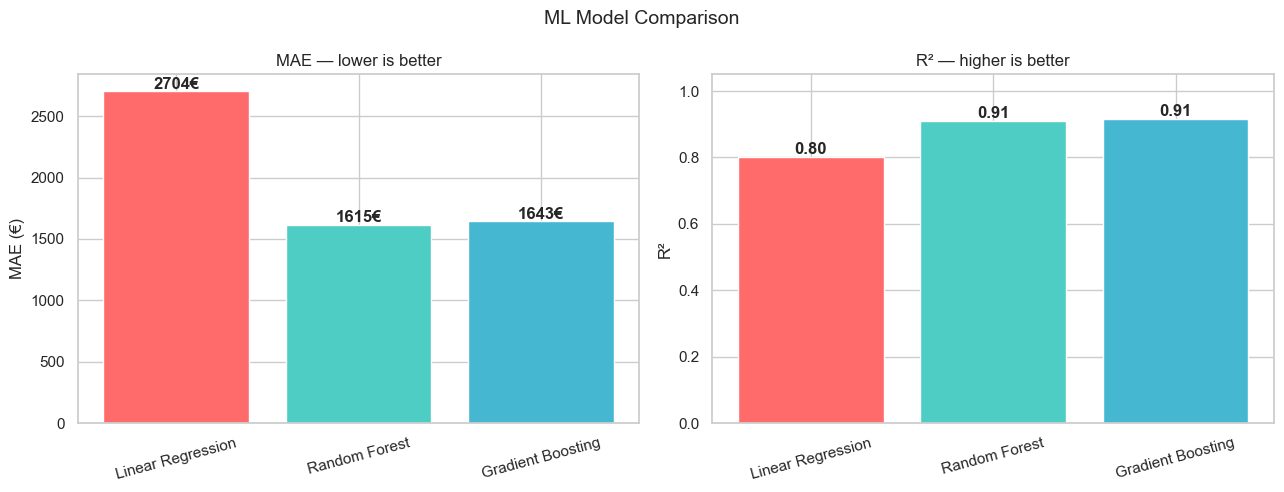

In [51]:
from sklearn.ensemble import GradientBoostingRegressor

# --- Model 3: Gradient Boosting ---
# Idea: each new tree corrects the errors of the previous one
gb_model = GradientBoostingRegressor(
    n_estimators=200,   # 200 trees
    learning_rate=0.1,  # how aggressively the model learns
    max_depth=4,        # depth of each tree
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb  = r2_score(y_test, y_pred_gb)

print(f'Gradient Boosting - MAE: {mae_gb:.1f} €')
print(f'Gradient Boosting - R2:  {r2_gb:.2f}')

# --- Model comparison table ---
print('\n' + '='*50)
print('MODEL COMPARISON')
print('='*50)

df_results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE (€)':  [2704.3, 1615.0, mae_gb],
    'R²':       [0.80,   0.91,   r2_gb],
})
print(df_results.to_string(index=False))

# Comparison chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

axes[0].bar(df_results['Model'], df_results['MAE (€)'], color=colors, edgecolor='white')
axes[0].set_title('MAE — lower is better', fontsize=12)
axes[0].set_ylabel('MAE (€)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(df_results['MAE (€)']):
    axes[0].text(i, v + 20, f'{v:.0f}€', ha='center', fontweight='bold')

axes[1].bar(df_results['Model'], df_results['R²'], color=colors, edgecolor='white')
axes[1].set_title('R² — higher is better', fontsize=12)
axes[1].set_ylabel('R²')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(df_results['R²']):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')

plt.suptitle('ML Model Comparison', fontsize=14)
plt.tight_layout()
plt.show()

In [33]:
# Save model results for Tableau
df_model_results = pd.DataFrame({
    'Modell': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE':    [mae, mae_rf, mae_gb],
    'R2':     [r2,  r2_rf,  r2_gb],
})
df_model_results.to_csv('model_results.csv', index=False)
print(f"✅ model_results.csv saved")
print(df_model_results)

✅ model_results.csv saved
              Modell          MAE        R2
0  Linear Regression  2704.282986  0.799227
1      Random Forest  1614.992194  0.913916
2  Gradient Boosting  1643.265743  0.914486
